## a* experiments

load a csv generated by `astar.py`, summarize the run, and create charts for runtime, memory, and search size.

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fourxfour_csv_path = Path("astar_results_4x4.csv")
nowall_csv_path = Path("astar_results_6x6_no_walls.csv")

dataset_paths = {
    "4x4": fourxfour_csv_path,
    "6x6 no walls": nowall_csv_path,
}


def load_results(path, label):
    df = pd.read_csv(path)
    df["dataset"] = label
    df["matches_data"] = df["Expected_Moves"].isna() | (df["Expected_Moves"] == df["Found_Moves"])
    df["memory_per_state_kb"] = (df["Peak_Memory_MB"] * 1024) / df["Expanded_States"].clip(lower=1)
    return df.sort_values("Line").reset_index(drop=True)


results_by_dataset = {}
missing_files = []

for label, path in dataset_paths.items():
    if path.exists():
        results_by_dataset[label] = load_results(path, label)
    else:
        missing_files.append(str(path))

if not results_by_dataset:
    expected_files = ", ".join(str(path) for path in dataset_paths.values())
    raise FileNotFoundError(
        "no result csv files were found. expected one or more of: " + expected_files
    )

all_results = pd.concat(results_by_dataset.values(), ignore_index=True)

print("loaded datasets:", list(results_by_dataset.keys()))
if missing_files:
    print("missing files:", missing_files)

loaded datasets: ['4x4', '6x6 no walls']


In [26]:
def make_display_df(df):
    display_df = pd.DataFrame({
        "Moves": df["Found_Moves"],
        "Visited States": df["Expanded_States"],
        "Runtime (sec)": df["Runtime_sec"],
    })

    if df["Peak_Memory_MB"].notna().any():
        display_df["Peak Memory (MB)"] = df["Peak_Memory_MB"]

    return display_df


def show_summary_table(df, label):
    print(f"{label} summary")
    display(make_display_df(df).describe().round(6))

    status_counts = df["Status"].value_counts().rename_axis("Status").to_frame("Count")
    print(f"{label} status counts")
    display(status_counts)

    if df["Expected_Moves"].notna().any():
        match_rate = df["matches_data"].mean()
        print(f"{label} match rate: {match_rate:.4f}")


def plot_runtime_memory(df, label):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    runtime_df = df[(df["Expanded_States"] > 0) & (df["Runtime_sec"] > 0)]
    axes[0].scatter(runtime_df["Expanded_States"], runtime_df["Runtime_sec"], color="purple", alpha=0.45, s=10)
    axes[0].set_title("Runtime by States Explored")
    axes[0].set_xlabel("Total Visited States")
    axes[0].set_ylabel("Runtime (Seconds)")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].grid(True, alpha=0.3)

    memory_df = df.dropna(subset=["Peak_Memory_MB", "Expanded_States", "memory_per_state_kb"])
    memory_df = memory_df[(memory_df["Expanded_States"] > 0) & (memory_df["memory_per_state_kb"] > 0)]

    if len(memory_df) == 0:
        axes[1].text(0.5, 0.5, "memory data not available\nrun astar with --track-memory", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Memory Overhead per State Evaluated")
        axes[1].set_xlabel("Total Visited States")
        axes[1].set_ylabel("Peak Memory / Total States (KB)")
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].scatter(memory_df["Expanded_States"], memory_df["memory_per_state_kb"], color="blue", alpha=0.45, s=10)

        if len(memory_df) >= 2:
            x = np.log10(memory_df["Expanded_States"].to_numpy())
            y = np.log10(memory_df["memory_per_state_kb"].to_numpy())
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            y_line = slope * x_line + intercept
            axes[1].plot(10 ** x_line, 10 ** y_line, color="red")

        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
        axes[1].set_title("Memory Overhead per State Evaluated")
        axes[1].set_xlabel("Total Visited States")
        axes[1].set_ylabel("Peak Memory / Total States (KB)")
        axes[1].grid(True, alpha=0.3)

    fig.suptitle(label)
    plt.tight_layout()
    plt.show()


def plot_solution_boxplot(df, label):
    unique_moves = sorted(df["Found_Moves"].dropna().unique())
    width = max(10, min(18, 0.35 * len(unique_moves)))

    ax = df.boxplot(column="Expanded_States", by="Found_Moves", grid=False, figsize=(width, 5))
    ax.set_title("Visited States by Solution Length")
    ax.figure.suptitle("")
    ax.set_xlabel("Solution Length (Moves to Solve T)")
    ax.set_ylabel("Visited States")
    ax.set_yscale("log")

    if len(unique_moves) > 20:
        step = max(1, len(unique_moves) // 15)
        tick_positions = np.arange(1, len(unique_moves) + 1)
        tick_labels = [str(int(move)) if index % step == 0 else "" for index, move in enumerate(unique_moves)]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=0)
    else:
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

In [27]:
### 4x4 results

4x4 summary


,Moves,Visited States,Runtime (sec),Peak Memory (MB)
count,150.000000,150.000000,150.000000,150.000000
mean,3.700000,80.060000,0.005028,0.053921
std,1.958461,234.581942,0.016984,0.163824
min,1.000000,2.000000,0.000074,0.001830
25%,2.000000,4.000000,0.000163,0.005056
50%,4.000000,14.500000,0.000613,0.009880
75%,5.000000,55.500000,0.002775,0.032075
max,9.000000,1967.000000,0.146859,1.359980


4x4 status counts


,Count
Status,
OK,150


4x4 match rate: 1.0000


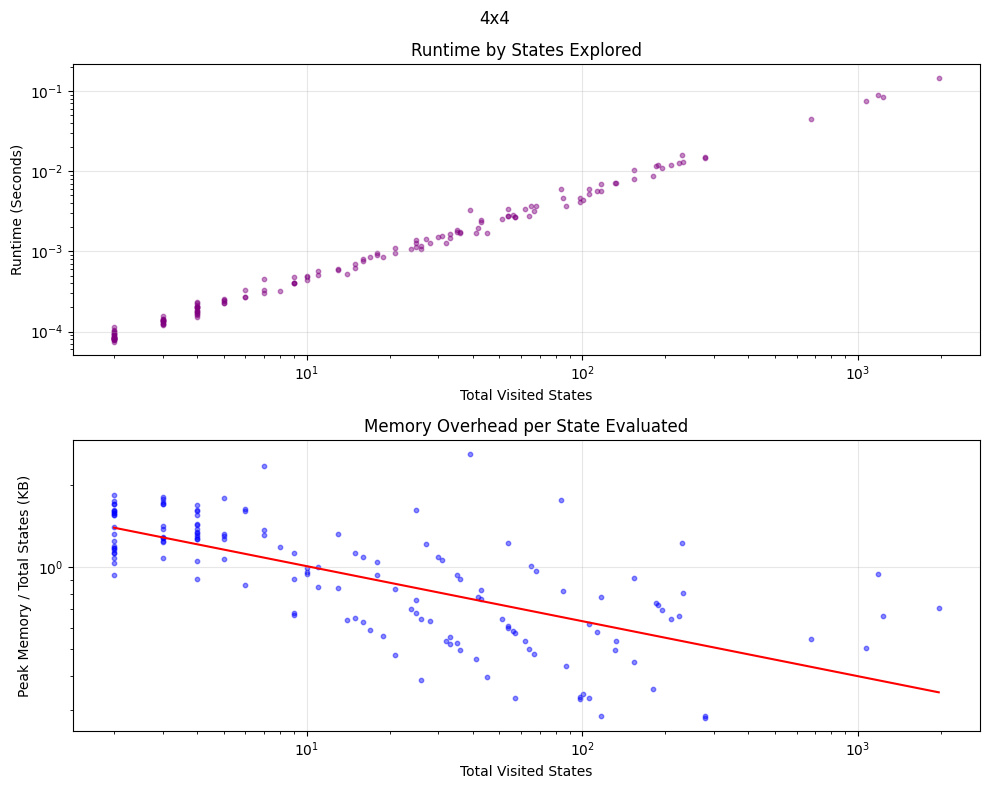

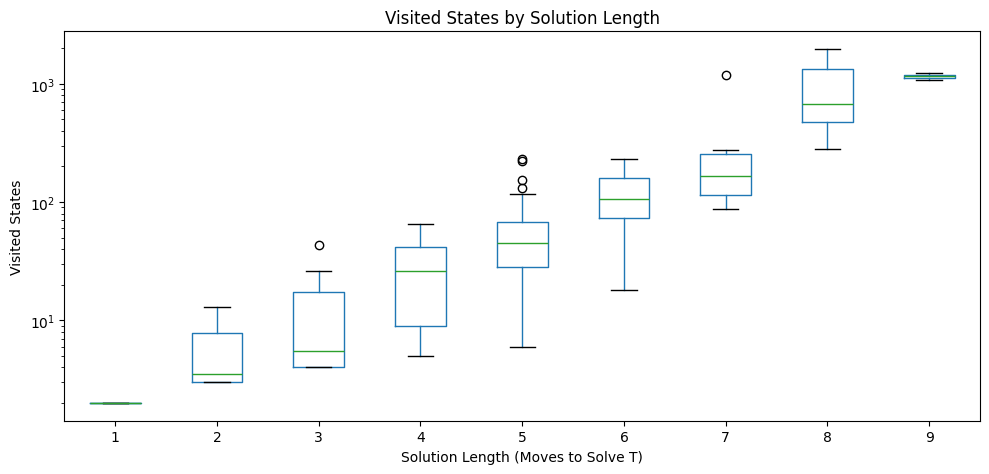

In [28]:
if "4x4" not in results_by_dataset:
    print("missing astar_results_4x4.csv")
else:
    df_4x4 = results_by_dataset["4x4"]
    show_summary_table(df_4x4, "4x4")
    plot_runtime_memory(df_4x4, "4x4")
    plot_solution_boxplot(df_4x4, "4x4")

In [29]:
### 6x6 no walls results

6x6 no walls summary


,Moves,Visited States,Runtime (sec),Peak Memory (MB)
count,476118.000000,476118.000000,476118.000000,476118.000000
mean,12.266146,1603.916731,0.019923,0.044115
std,4.188763,2505.694381,0.037910,0.273546
min,1.000000,5.000000,0.000058,0.000000
25%,10.000000,328.000000,0.002900,0.000000
50%,11.000000,788.000000,0.008034,0.000000
75%,14.000000,1844.000000,0.021161,0.000000
max,51.000000,106099.000000,2.176753,23.656250


6x6 no walls status counts


,Count
Status,
OK,476118


6x6 no walls match rate: 1.0000


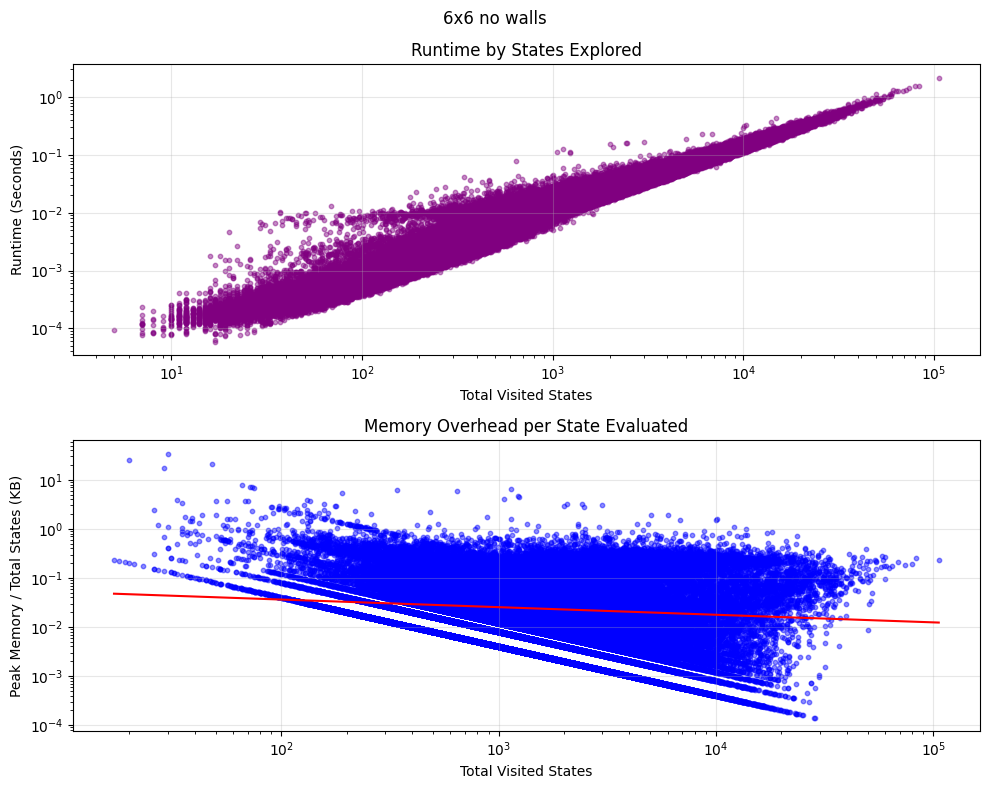

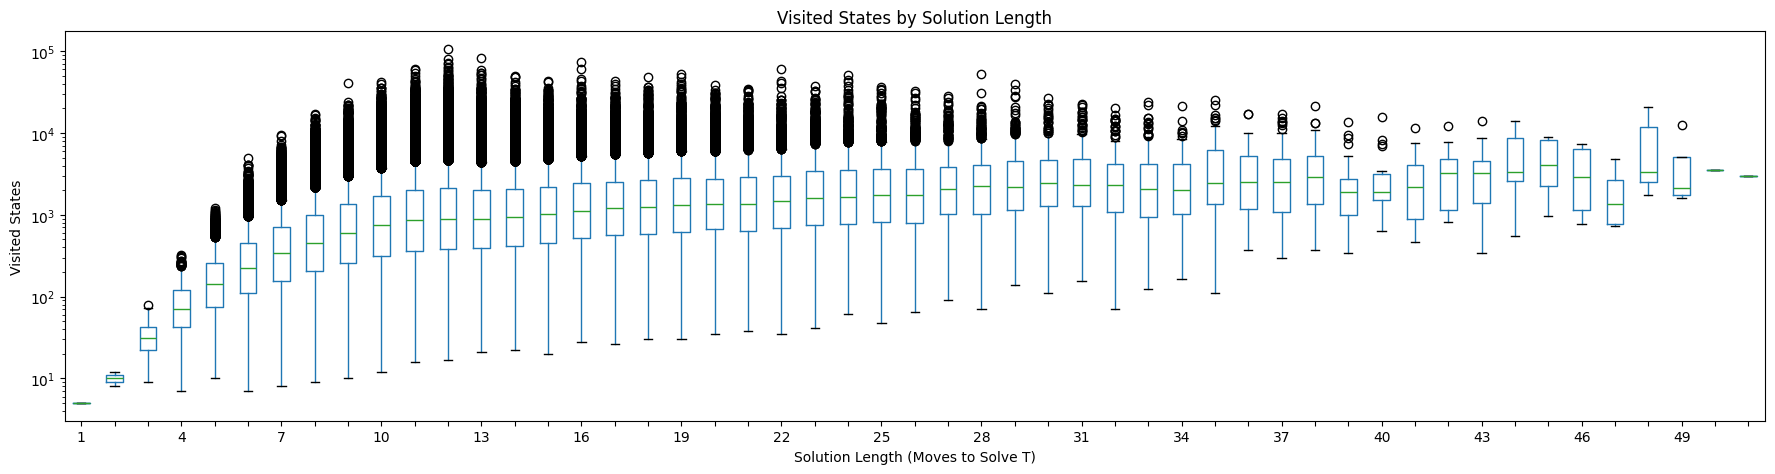

In [30]:
if "6x6 no walls" not in results_by_dataset:
    print("missing astar_results_6x6_no_walls.csv")
else:
    df_no_walls = results_by_dataset["6x6 no walls"]
    show_summary_table(df_no_walls, "6x6 no walls")
    plot_runtime_memory(df_no_walls, "6x6 no walls")
    plot_solution_boxplot(df_no_walls, "6x6 no walls")